# Bài 2 — Feature Selection dựa trên Correlation

**Bài toán hồi quy:** dự đoán `log_income = log(1 + income)` — số tiền (satoshi) mà một địa chỉ Bitcoin nhận được
trong một ngày — từ các đặc trưng còn lại của bộ dữ liệu *BitcoinHeist* (UCI, 2.916.697 dòng).

**Vì sao không dùng nhãn phân loại của Bài 1?** Linear Regression là mô hình **hồi quy** và MAE là độ đo **hồi quy**
→ cần biến mục tiêu **liên tục**. Nhãn của Bài 1 gồm 7 lớp danh nghĩa (không có thứ tự): đánh số 0…6 rồi hồi quy là
vô nghĩa. `income` là biến liên tục có ý nghĩa thực tế: *"địa chỉ này nhận bao nhiêu tiền?"*.

**Nội dung**
1. Đọc dữ liệu & xác định bài toán
2. Chia train / test
3. **(a)** Chọn đặc trưng dựa trên tương quan — các đồ thị minh hoạ
4. **(b)** Thử nghiệm các tập đặc trưng với Linear Regression — so sánh MAE
5. Kết luận

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import r_regression, f_regression, SelectKBest
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

DATA_PATH = "BitcoinHeistData.csv"
OUT_DIR = "outputs/bai2"
APP_DIR = "proj1/data/bai2"          # kết quả dùng cho demo Streamlit (Bài 3)
RANDOM_STATE = 42
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(APP_DIR, exist_ok=True)

## 1. Đọc dữ liệu & xác định bài toán

| Vai trò | Cột | Xử lý |
|---|---|---|
| **Mục tiêu** `y` | `income` | `log1p` — income lệch rất mạnh (0,3 BTC → gần 500.000 BTC) |
| Đặc trưng đồ thị | `length, weight, count, looped, neighbors` | `log1p` (lệch mạnh, như Bài 1) |
| Đặc trưng tỉ lệ (tạo mới) | `weight_per_count = weight/count`, `looped_ratio = looped/count` | `log1p` |
| Thời gian | `year, day, month, weekday` | giữ nguyên (số) |
| Nhãn | `is_ransom` = 1 nếu là ransomware, 0 nếu `white` | nhị phân |

→ **12 đặc trưng** thuộc nhiều kiểu (số liên tục, số đếm, thời gian, nhị phân).

**Không dùng:** `address` (định danh), và các đặc trưng tạo từ `income` ở Bài 1 (`income_tz`, `income_per_count`,
`income_per_neighbor`) — chúng chứa chính biến mục tiêu → **rò rỉ dữ liệu** (data leakage).

In [2]:
t0 = time.perf_counter()
df = pd.read_csv(DATA_PATH)
date = pd.to_datetime(df["year"].astype(str) + "-01-01") + pd.to_timedelta(df["day"] - 1, unit="D")
df["month"] = date.dt.month
df["weekday"] = date.dt.dayofweek
df["weight_per_count"] = df["weight"] / df["count"]
df["looped_ratio"] = df["looped"] / df["count"]
df["is_ransom"] = (df["label"] != "white").astype(int)

SKEWED = ["length", "weight", "count", "looped", "neighbors", "weight_per_count", "looped_ratio"]
OTHER = ["year", "day", "month", "weekday", "is_ransom"]
FEATURES = SKEWED + OTHER
TARGET = "log_income"

X = pd.concat([np.log1p(df[SKEWED]), df[OTHER]], axis=1)[FEATURES]
y = np.log1p(df["income"]).rename(TARGET)
print(f"Đọc & tạo đặc trưng trong {time.perf_counter() - t0:.1f}s — {len(X):,} dòng × {X.shape[1]} đặc trưng")
pd.concat([X, y], axis=1).describe().T[["mean", "std", "min", "max"]]

Đọc & tạo đặc trưng trong 2.6s — 2,916,697 dòng × 12 đặc trưng


,mean,std,min,max
length,2.4529,1.9039,0.0000,4.9767
weight,0.3277,0.3557,0.0000,7.5729
count,2.6487,2.9472,0.6931,9.5818
looped,0.7667,2.2038,0.0000,9.5817
neighbors,1.0150,0.3149,0.6931,9.4666
weight_per_count,0.2318,0.2732,0.0000,1.0986
looped_ratio,0.0818,0.2164,0.0000,0.6931
year,2014.4750,2.2574,2011.0000,2018.0000
day,181.4572,104.0118,1.0000,365.0000
month,6.4685,3.4042,1.0000,12.0000


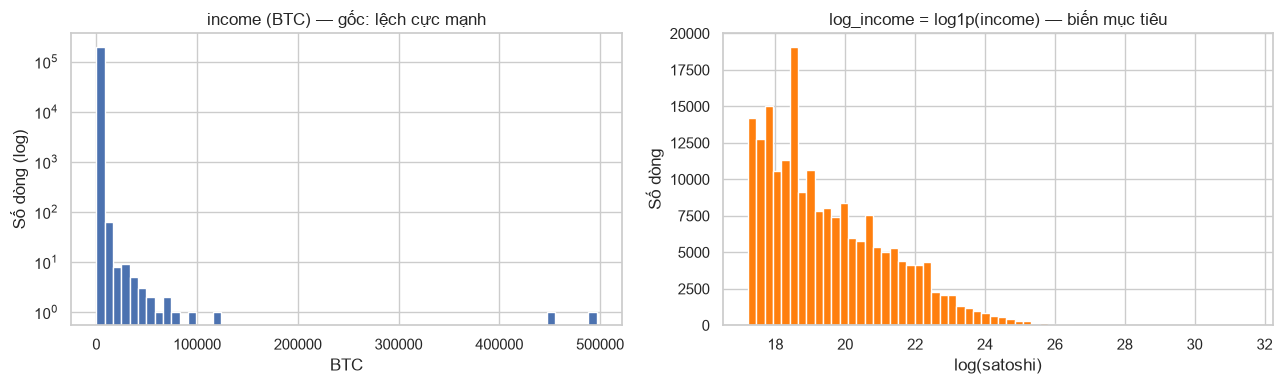

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
s = df["income"].sample(200_000, random_state=RANDOM_STATE)
axes[0].hist(s / 1e8, bins=60)
axes[0].set(title="income (BTC) — gốc: lệch cực mạnh", yscale="log", xlabel="BTC", ylabel="Số dòng (log)")
axes[1].hist(np.log1p(s), bins=60, color="tab:orange")
axes[1].set(title="log_income = log1p(income) — biến mục tiêu", xlabel="log(satoshi)", ylabel="Số dòng")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/target_distribution.png", dpi=120); plt.show()

## 2. Chia train / test

80% train / 20% test (ngẫu nhiên, `random_state=42`). **Hệ số tương quan và việc chọn đặc trưng chỉ tính trên tập
train**; tập test chỉ dùng để đo MAE → kết quả không bị "nhìn trộm" dữ liệu test.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,} dòng | Test: {len(X_test):,} dòng")

Train: 2,333,357 dòng | Test: 583,340 dòng


## 3. (a) Chọn đặc trưng dựa trên tương quan (Correlation-based Feature Selection)

**Hệ số tương quan Pearson** giữa đặc trưng $X$ và mục tiêu $Y$:

$$r = \frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sqrt{\sum_i (x_i-\bar x)^2}\,\sqrt{\sum_i (y_i-\bar y)^2}} \in [-1, 1]$$

- $|r|$ gần 1 → quan hệ **tuyến tính** mạnh; $r \approx 0$ → không có quan hệ tuyến tính.
- Dấu của $r$: $+$ cùng chiều ($X$ tăng → $Y$ tăng), $-$ ngược chiều.
- Pearson phù hợp với Linear Regression vì cả hai cùng mô tả quan hệ tuyến tính (hồi quy 1 biến: $R^2 = r^2$).
- Tính trên dữ liệu đã `log1p` — đúng dạng dữ liệu đưa vào mô hình.

**Hai nguyên tắc chọn đặc trưng:**
1. **Liên quan (relevance):** giữ các đặc trưng có $|r(X_j, Y)|$ lớn — mang nhiều thông tin về mục tiêu.
   Hai cách chọn: **Top-k** ($k$ đặc trưng có $|r|$ lớn nhất) hoặc **ngưỡng** ($|r| \ge t$).
2. **Không dư thừa (redundancy):** nếu hai đặc trưng tương quan rất mạnh *với nhau* ($|r(X_i, X_j)| \ge$ ngưỡng),
   chúng mang thông tin trùng lặp → bỏ đặc trưng có $|r|$ với mục tiêu thấp hơn.

### 3.1 Tương quan giữa từng đặc trưng và mục tiêu

In [5]:
corr_target = pd.DataFrame({"pearson": X_train.corrwith(y_train),
                            "spearman": X_train.corrwith(y_train, method="spearman")})
corr_target["abs_pearson"] = corr_target["pearson"].abs()
corr_target = corr_target.sort_values("abs_pearson", ascending=False)
corr_target.insert(0, "hạng", range(1, len(corr_target) + 1))
RANKING = corr_target.index.tolist()          # đặc trưng xếp theo |r| giảm dần
corr_target

,hạng,pearson,spearman,abs_pearson
year,1,-0.2850,-0.2811,0.2850
neighbors,2,0.1980,0.1558,0.1980
weight,3,0.0888,0.0131,0.0888
count,4,-0.0594,-0.0264,0.0594
weight_per_count,5,-0.0501,-0.0192,0.0501
length,6,0.0366,0.0381,0.0366
is_ransom,7,-0.0362,-0.0274,0.0362
month,8,-0.0251,-0.0225,0.0251
looped_ratio,9,0.0250,0.0448,0.0250
day,10,-0.0250,-0.0225,0.0250


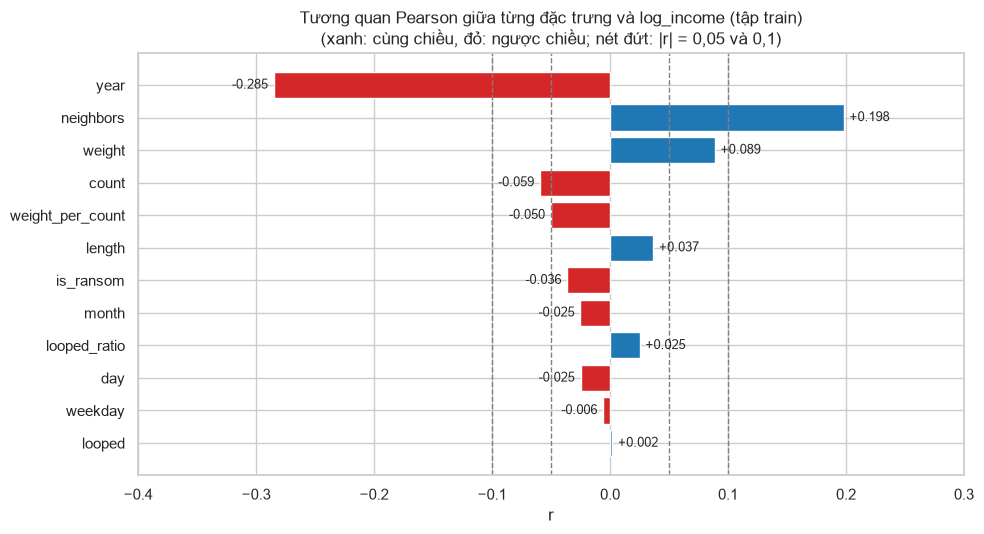

In [6]:
r = corr_target["pearson"][::-1]
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(r.index, r.values, color=np.where(r.values > 0, "tab:blue", "tab:red"))
for t in (0.05, 0.1):
    for sign in (1, -1):
        ax.axvline(sign * t, ls="--", c="gray", lw=1)
for i, v in enumerate(r.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i, f"{v:+.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.set(title="Tương quan Pearson giữa từng đặc trưng và log_income (tập train)\n(xanh: cùng chiều, đỏ: ngược chiều; "
             "nét đứt: |r| = 0,05 và 0,1)", xlabel="r", xlim=(-0.4, 0.3))
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/corr_with_target.png", dpi=120); plt.show()

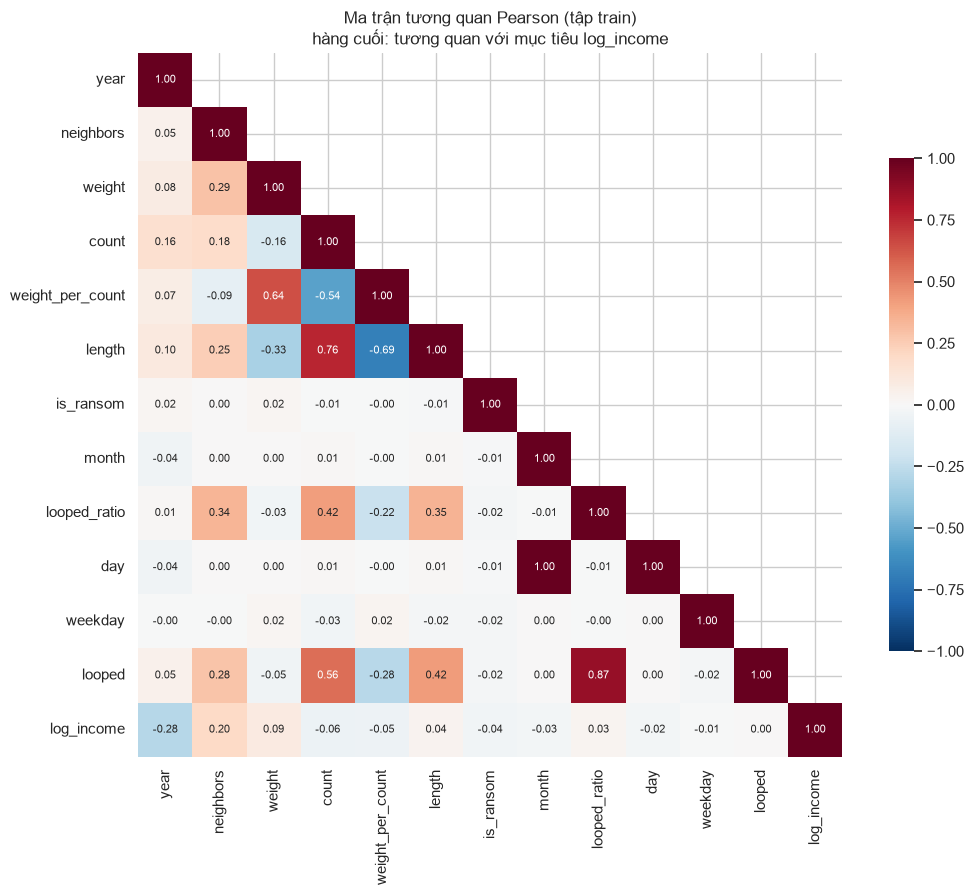

In [7]:
corr_all = pd.concat([X_train, y_train], axis=1).corr().loc[RANKING + [TARGET], RANKING + [TARGET]]
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_all, mask=np.triu(np.ones_like(corr_all, dtype=bool), k=1), annot=True, fmt=".2f",
            cmap="RdBu_r", vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Ma trận tương quan Pearson (tập train)\nhàng cuối: tương quan với mục tiêu log_income")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/corr_heatmap.png", dpi=120); plt.show()

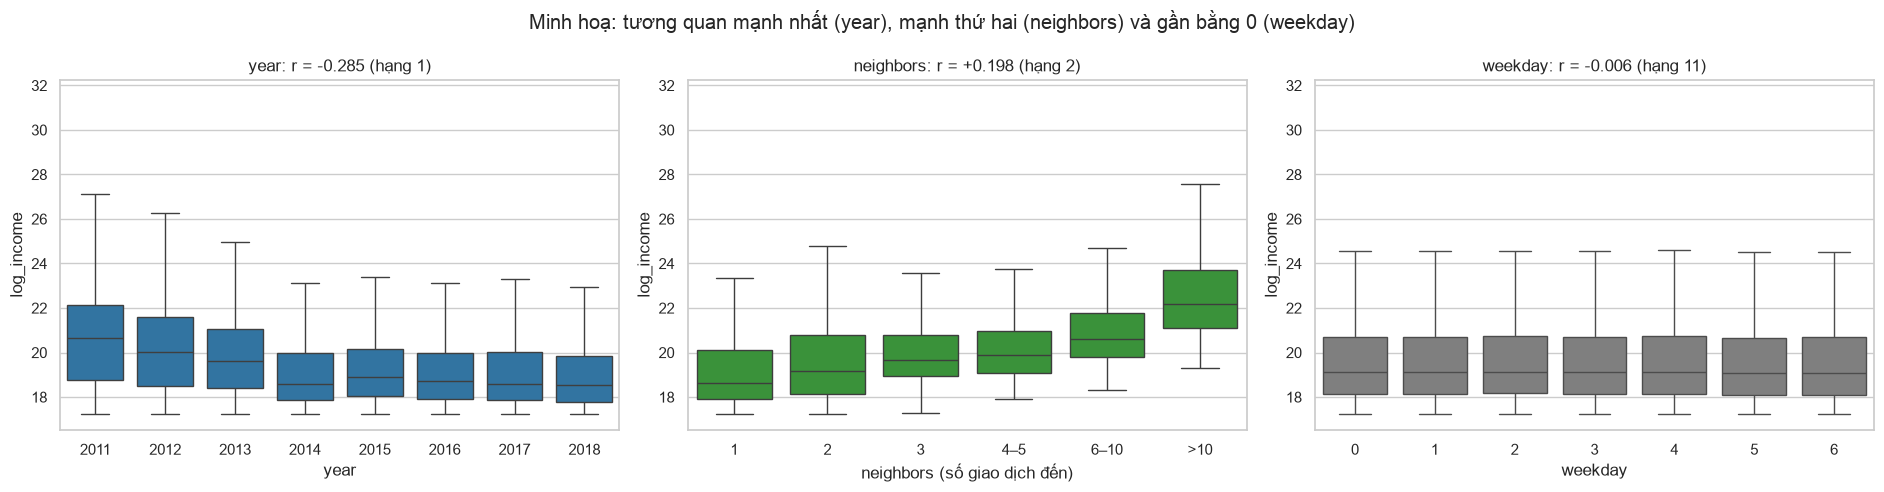

In [8]:
smp = pd.concat([X_train, y_train], axis=1).sample(200_000, random_state=RANDOM_STATE)
smp["neighbors_bin"] = pd.cut(np.expm1(smp["neighbors"]).round(), [0, 1, 2, 3, 5, 10, np.inf],
                              labels=["1", "2", "3", "4–5", "6–10", ">10"])
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
panels = [("year", "year", "tab:blue"), ("neighbors_bin", "neighbors", "tab:green"), ("weekday", "weekday", "tab:gray")]
for ax, (xcol, feat, color) in zip(axes, panels):
    sns.boxplot(data=smp, x=xcol, y=TARGET, ax=ax, color=color, fliersize=0)
    ax.set(title=f"{feat}: r = {corr_target.loc[feat, 'pearson']:+.3f} (hạng {corr_target.loc[feat, 'hạng']})",
           xlabel=feat if feat != "neighbors" else "neighbors (số giao dịch đến)")
plt.suptitle("Minh hoạ: tương quan mạnh nhất (year), mạnh thứ hai (neighbors) và gần bằng 0 (weekday)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/corr_illustration.png", dpi=120); plt.show()

**Nhận xét (3.1):**
- `year` tương quan mạnh nhất và **âm** (r = −0,285): số satoshi nhận được giảm mạnh từ 2011 đến 2014 rồi gần như ổn
  định. Có thể giải thích: giá BTC tăng rất mạnh qua các năm nên cùng một giá trị tiền chỉ cần ít satoshi hơn.
- `neighbors` đứng thứ hai và **dương** (r = +0,198): càng nhiều giao dịch gửi đến, địa chỉ càng nhận nhiều tiền.
- `month`, `day`, `weekday`, `looped` gần như **không** có quan hệ tuyến tính với income (|r| ≤ 0,025).
- Mọi |r| đều nhỏ (< 0,3) → quan hệ tuyến tính với income là **yếu**; Linear Regression sẽ chỉ giải thích được một
  phần nhỏ biến động của income.

### 3.2 Tương quan giữa các đặc trưng — phát hiện đặc trưng dư thừa

Thuật toán (tham lam): duyệt các đặc trưng theo $|r|$ với mục tiêu **giảm dần**; giữ một đặc trưng nếu nó **không**
tương quan mạnh ($|r| \ge$ ngưỡng) với bất kỳ đặc trưng nào đã giữ trước đó.

In [9]:
corr_ff = X_train.corr()
pairs = (corr_ff.where(np.triu(np.ones(corr_ff.shape, dtype=bool), k=1)).stack()
         .rename("r").reset_index().rename(columns={"level_0": "đặc trưng 1", "level_1": "đặc trưng 2"}))
pairs = pairs.reindex(pairs["r"].abs().sort_values(ascending=False).index).reset_index(drop=True)

def drop_redundant(features, thr):
    kept = []
    for f in sorted(features, key=RANKING.index):          # đặc trưng liên quan nhất được xét trước
        if all(abs(corr_ff.loc[f, g]) < thr for g in kept):
            kept.append(f)
    return kept

for thr in (0.9, 0.7):
    print(f"Ngưỡng dư thừa {thr}: bỏ {[f for f in RANKING if f not in drop_redundant(FEATURES, thr)]}")
pairs.head(8)

Ngưỡng dư thừa 0.9: bỏ ['day']
Ngưỡng dư thừa 0.7: bỏ ['length', 'day', 'looped']


,đặc trưng 1,đặc trưng 2,r
0,day,month,0.9964
1,looped,looped_ratio,0.8676
2,length,count,0.7588
3,length,weight_per_count,-0.6874
4,weight,weight_per_count,0.6443
5,count,looped,0.5557
6,count,weight_per_count,-0.5430
7,length,looped,0.4248


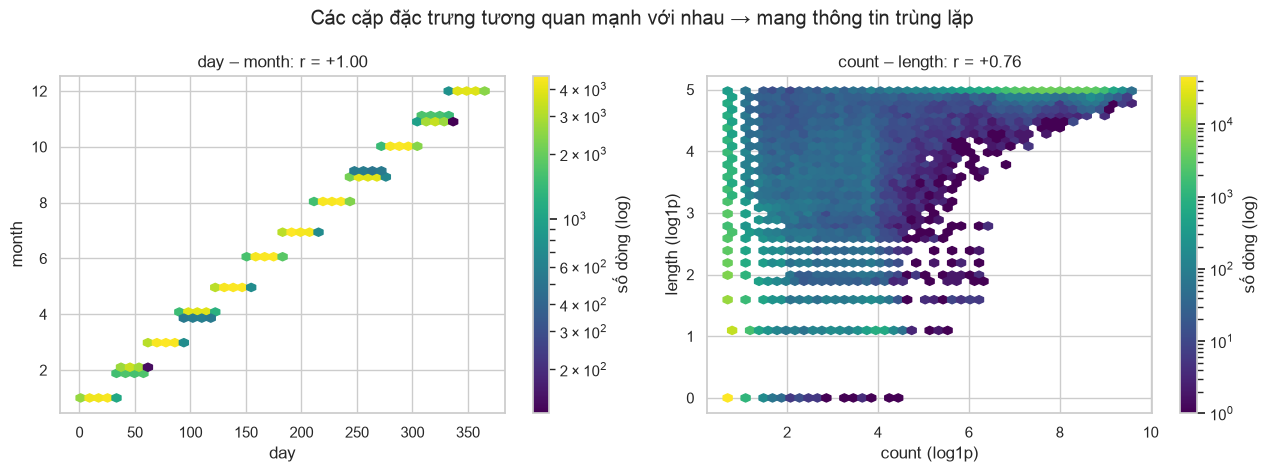

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (a, b) in zip(axes, [("day", "month"), ("count", "length")]):
    hb = ax.hexbin(smp[a], smp[b], gridsize=45, bins="log", cmap="viridis", mincnt=1)
    ax.set(xlabel=a + (" (log1p)" if a in SKEWED else ""), ylabel=b + (" (log1p)" if b in SKEWED else ""),
           title=f"{a} – {b}: r = {corr_ff.loc[a, b]:+.2f}")
    fig.colorbar(hb, ax=ax, label="số dòng (log)")
plt.suptitle("Các cặp đặc trưng tương quan mạnh với nhau → mang thông tin trùng lặp")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/redundancy_pairs.png", dpi=120); plt.show()

**Nhận xét (3.2):**
- `day` – `month`: r = 0,996 — gần như trùng thông tin (month suy ra trực tiếp từ day) → `day` **dư thừa**.
- `looped` – `looped_ratio` (r = 0,87), `length` – `count` (r = 0,76): tương quan mạnh nhưng chưa trùng hoàn toàn.
- Ngưỡng 0,9 chỉ loại `day`; ngưỡng 0,7 loại thêm `looped` và `length`.

### 3.3 So sánh Pearson và Spearman

Spearman = Pearson tính trên **thứ hạng** → đo quan hệ **đơn điệu** (không cần tuyến tính), ít bị ảnh hưởng bởi
giá trị ngoại lai. Nếu hai phương pháp cho thứ hạng gần giống nhau → kết quả chọn đặc trưng đáng tin cậy.

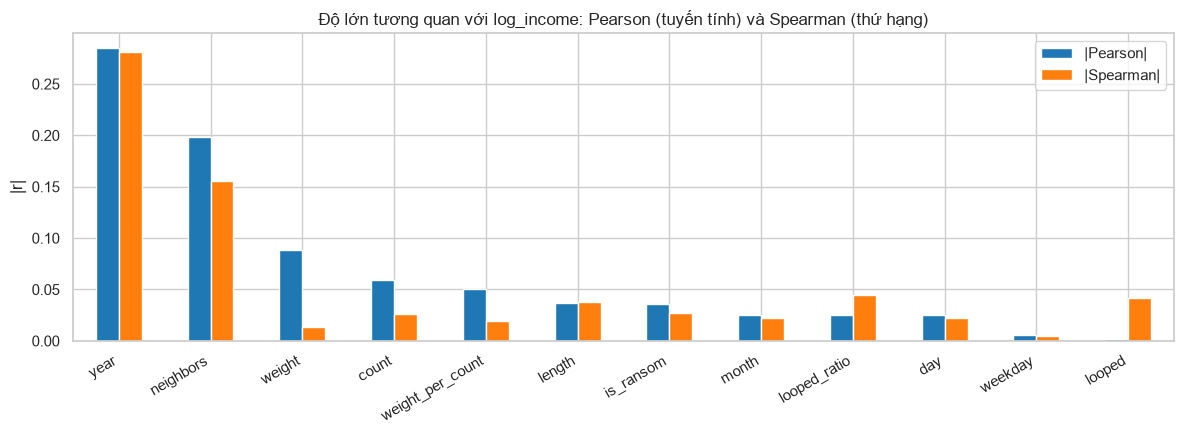

Top-6 theo Pearson : ['year', 'neighbors', 'weight', 'count', 'weight_per_count', 'length']
Top-6 theo Spearman: ['year', 'neighbors', 'looped_ratio', 'looped', 'length', 'is_ransom']


In [11]:
cmp_ = corr_target[["pearson", "spearman"]].abs().rename(columns={"pearson": "|Pearson|", "spearman": "|Spearman|"})
ax = cmp_.plot.bar(figsize=(12, 4.5), color=["tab:blue", "tab:orange"])
ax.set(title="Độ lớn tương quan với log_income: Pearson (tuyến tính) và Spearman (thứ hạng)", ylabel="|r|", xlabel="")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/pearson_vs_spearman.png", dpi=120); plt.show()
print("Top-6 theo Pearson :", RANKING[:6])
print("Top-6 theo Spearman:", corr_target["spearman"].abs().sort_values(ascending=False).index[:6].tolist())

**Nhận xét (3.3):** Hai phương pháp thống nhất ở 2 đặc trưng quan trọng nhất (`year`, `neighbors`). Ở nhóm sau có
khác biệt: Spearman xếp `looped_ratio`, `looped` cao hơn và `weight` thấp hơn nhiều (Pearson 0,089 → Spearman 0,013) —
dấu hiệu của quan hệ **đơn điệu nhưng không tuyến tính**. Vì mô hình ở câu (b) là **Linear Regression** (tuyến tính),
ta dùng **Pearson** làm tiêu chí chính; mục 4.4 kiểm chứng lựa chọn này.

### 3.4 Đối chiếu với `sklearn.feature_selection`

- `r_regression`: tính hệ số Pearson $r$ của từng đặc trưng với mục tiêu — trùng với cách tính thủ công ở trên.
- `f_regression`: kiểm định F, $F = \frac{r^2}{1-r^2}(n-2)$ — tăng theo $|r|$ → `SelectKBest(f_regression, k)`
  chọn đúng $k$ đặc trưng có $|r|$ lớn nhất.

In [12]:
F, pval = f_regression(X_train, y_train)
sk = pd.DataFrame({"r (thủ công)": corr_target["pearson"],
                   "r_regression": pd.Series(r_regression(X_train, y_train), index=FEATURES),
                   "F": pd.Series(F, index=FEATURES), "p-value": pd.Series(pval, index=FEATURES)}).loc[RANKING]
sel = SelectKBest(f_regression, k=6).fit(X_train, y_train)
print("SelectKBest(f_regression, k=6):", sorted(X_train.columns[sel.get_support()]))
print("Top-6 theo |r| (thủ công)     :", sorted(RANKING[:6]))
assert set(X_train.columns[sel.get_support()]) == set(RANKING[:6])
sk.style.format({"r (thủ công)": "{:+.4f}", "r_regression": "{:+.4f}", "F": "{:,.0f}", "p-value": "{:.2e}"})

SelectKBest(f_regression, k=6): ['count', 'length', 'neighbors', 'weight', 'weight_per_count', 'year']
Top-6 theo |r| (thủ công)     : ['count', 'length', 'neighbors', 'weight', 'weight_per_count', 'year']


,r (thủ công),r_regression,F,p-value
year,-0.2850,-0.2850,"206,258",0.00e+00
neighbors,+0.1980,+0.1980,"95,200",0.00e+00
weight,+0.0888,+0.0888,"18,535",0.00e+00
count,-0.0594,-0.0594,"8,254",0.00e+00
weight_per_count,-0.0501,-0.0501,"5,877",0.00e+00
length,+0.0366,+0.0366,"3,122",0.00e+00
is_ransom,-0.0362,-0.0362,"3,063",0.00e+00
month,-0.0251,-0.0251,"1,471",0.00e+00
looped_ratio,+0.0250,+0.0250,"1,463",0.00e+00
day,-0.0250,-0.0250,"1,458",0.00e+00


**Nhận xét (3.4):** `r_regression` cho đúng các hệ số đã tính; `SelectKBest(f_regression, k=6)` chọn đúng 6 đặc trưng
có |r| lớn nhất. Với 2,3 triệu dòng, gần như mọi tương quan đều "có ý nghĩa thống kê" (p-value < 0,05, kể cả `looped`
với r chỉ 0,002) → **p-value không giúp phân biệt**; cần dựa vào **độ lớn** |r| và kiểm chứng bằng MAE ở câu (b).

## 4. (b) Thử nghiệm các tập đặc trưng với Linear Regression — so sánh MAE

- **Mô hình:** `StandardScaler` → `LinearRegression`: $\hat y = w_0 + w_1x_1 + \dots + w_kx_k$, tìm $w$ bằng bình
  phương tối thiểu. Chuẩn hoá không làm thay đổi dự đoán của Linear Regression nhưng giúp so sánh độ lớn các hệ số.
- **Độ đo:** $\text{MAE} = \frac{1}{n}\sum_i |y_i - \hat y_i|$ — cùng đơn vị với $y$; **càng nhỏ càng tốt**.
  Vì $y$ là log, MAE $= m$ nghĩa là dự đoán lệch trung bình khoảng $e^{m}$ lần so với income thật.
- **Mốc so sánh (baseline):** không dùng đặc trưng nào, luôn dự đoán trung bình của $y$ trên tập train.
- Train trên tập train, đo MAE trên tập test. Cột **% cải thiện** = mức giảm MAE so với baseline, lấy mức giảm khi
  dùng **toàn bộ 12 đặc trưng** làm 100%.

In [13]:
def evaluate(name, cols):
    cols = list(cols)
    if cols:
        model = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
        t0 = time.perf_counter(); model.fit(X_train[cols], y_train); t_train = time.perf_counter() - t0
        pred = model.predict(X_test[cols])
    else:                                       # baseline: luôn dự đoán trung bình của y_train
        model, t_train, pred = None, 0.0, np.full(len(y_test), y_train.mean())
    return {"tập đặc trưng": name, "số đặc trưng": len(cols), "MAE": mean_absolute_error(y_test, pred),
            "R2": r2_score(y_test, pred), "train_time_s": t_train, "đặc trưng": ", ".join(cols)}, model

def improvement(mae):
    return 100 * (BASE["MAE"] - mae) / (BASE["MAE"] - ALL["MAE"])

BASE, _ = evaluate("Baseline (dự đoán trung bình)", [])
ALL, _ = evaluate(f"Tất cả {len(FEATURES)} đặc trưng", FEATURES)
pd.DataFrame([BASE, ALL]).set_index("tập đặc trưng")

,số đặc trưng,MAE,R2,train_time_s,đặc trưng
tập đặc trưng,,,,,
Baseline (dự đoán trung bình),0,1.4641,-0.0000,0.0000,
Tất cả 12 đặc trưng,12,1.3300,0.1494,0.3551,"length, weight, count, looped, neighbors, weight_per_count, looped_ratio, year, day, month, weekday, is_ransom"


### 4.1 Top-k: thêm dần đặc trưng theo thứ tự $|r|$ giảm dần

In [14]:
topk = pd.DataFrame([evaluate(f"Top-{k}", RANKING[:k])[0] for k in range(len(RANKING) + 1)])
topk.loc[0, "tập đặc trưng"] = "Top-0 (baseline)"
topk.insert(1, "đặc trưng thêm vào", ["—"] + RANKING)
topk["% cải thiện"] = improvement(topk["MAE"])
K_BEST = int(topk.loc[topk["% cải thiện"] >= 95, "số đặc trưng"].min())   # k nhỏ nhất đạt ≥ 95% mức cải thiện
print(f"K_BEST = {K_BEST}: {RANKING[:K_BEST]}")
topk.drop(columns="đặc trưng").set_index("tập đặc trưng")

K_BEST = 6: ['year', 'neighbors', 'weight', 'count', 'weight_per_count', 'length']


,đặc trưng thêm vào,số đặc trưng,MAE,R2,train_time_s,% cải thiện
tập đặc trưng,,,,,,
Top-0 (baseline),—,0,1.4641,-0.0000,0.0000,0.0000
Top-1,year,1,1.3907,0.0804,0.0339,54.7289
Top-2,neighbors,2,1.3507,0.1253,0.0529,84.5435
Top-3,weight,3,1.3483,0.1281,0.0730,86.3646
Top-4,count,4,1.3477,0.1298,0.1234,86.7798
Top-5,weight_per_count,5,1.3386,0.1412,0.1295,93.5321
Top-6,length,6,1.3325,0.1465,0.1431,98.1292
Top-7,is_ransom,7,1.3315,0.1477,0.1563,98.8447
Top-8,month,8,1.3305,0.1489,0.1737,99.6432


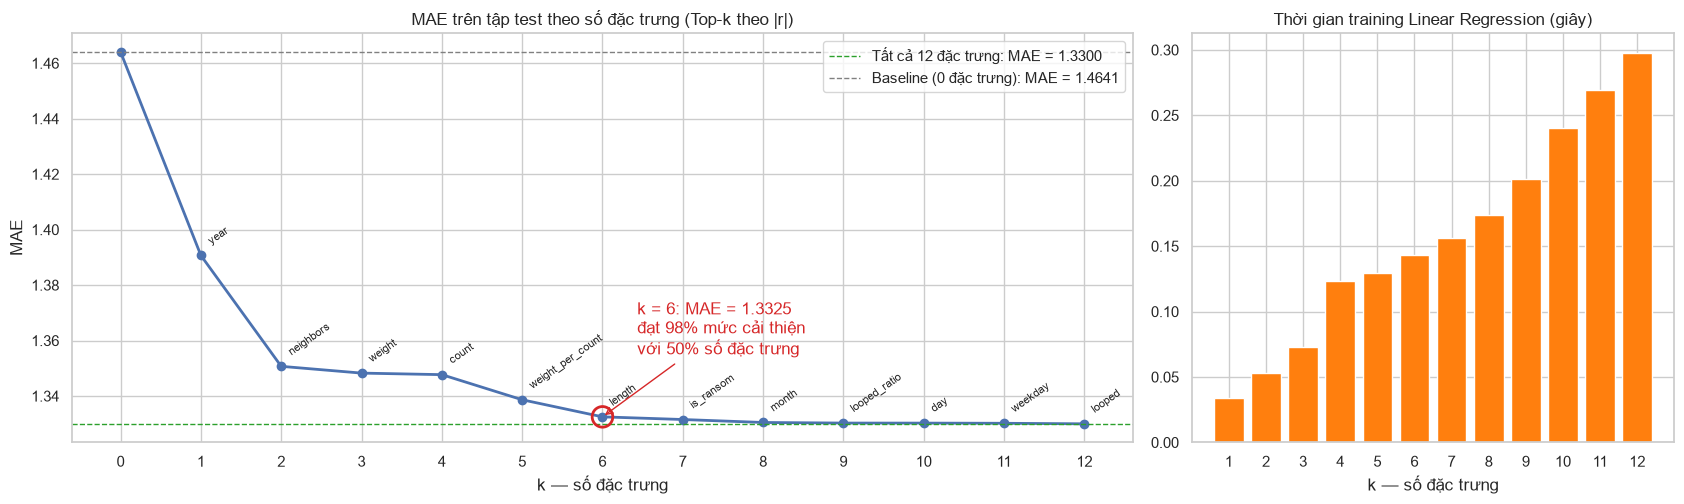

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5.2), gridspec_kw={"width_ratios": [2.2, 1]})
ax = axes[0]
ax.plot(topk["số đặc trưng"], topk["MAE"], marker="o", lw=2)
for _, row in topk.iloc[1:].iterrows():
    ax.annotate(row["đặc trưng thêm vào"], (row["số đặc trưng"], row["MAE"]), textcoords="offset points",
                xytext=(4, 8), fontsize=8, rotation=35)
best = topk.loc[K_BEST]
ax.scatter([K_BEST], [best["MAE"]], s=220, facecolors="none", edgecolors="tab:red", lw=2, zorder=5)
ax.annotate(f"k = {K_BEST}: MAE = {best['MAE']:.4f}\nđạt {best['% cải thiện']:.0f}% mức cải thiện\n"
            f"với {100 * K_BEST / len(FEATURES):.0f}% số đặc trưng", (K_BEST, best["MAE"]),
            textcoords="offset points", xytext=(25, 45), color="tab:red", arrowprops={"arrowstyle": "->", "color": "tab:red"})
ax.axhline(ALL["MAE"], ls="--", c="tab:green", lw=1, label=f"Tất cả 12 đặc trưng: MAE = {ALL['MAE']:.4f}")
ax.axhline(BASE["MAE"], ls="--", c="gray", lw=1, label=f"Baseline (0 đặc trưng): MAE = {BASE['MAE']:.4f}")
ax.set(title="MAE trên tập test theo số đặc trưng (Top-k theo |r|)", xlabel="k — số đặc trưng", ylabel="MAE",
       xticks=range(len(RANKING) + 1))
ax.legend(loc="upper right")
axes[1].bar(topk["số đặc trưng"][1:], topk["train_time_s"][1:], color="tab:orange")
axes[1].set(title="Thời gian training Linear Regression (giây)", xlabel="k — số đặc trưng",
            xticks=range(1, len(RANKING) + 1))
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/mae_topk.png", dpi=120); plt.show()

**Nhận xét (4.1):**
- MAE giảm nhanh ở các đặc trưng đầu tiên rồi **bão hoà**: chỉ `year` đã đạt ~55% mức cải thiện; `year + neighbors`
  đạt ~85%; **Top-6 đạt ~98%** (MAE 1,3325 so với 1,3300 khi dùng cả 12 đặc trưng — chỉ chênh 0,0025, tức 0,19%).
- 6 đặc trưng cuối (|r| < 0,03) gần như không giúp gì thêm.
- Ít đặc trưng hơn → train nhanh hơn (Top-6 nhanh hơn khoảng 2 lần so với 12 đặc trưng) và ít tham số hơn
  (7 thay vì 13: k hệ số + 1 hệ số chặn).

### 4.2 Chọn theo ngưỡng: giữ các đặc trưng có $|r| \ge t$

In [16]:
thr_df = pd.DataFrame([evaluate(f"|r| ≥ {t}", [f for f in RANKING if corr_target.loc[f, "abs_pearson"] >= t])[0]
                       for t in (0.2, 0.1, 0.05, 0.03, 0.02, 0.01, 0.0)])
thr_df["% cải thiện"] = improvement(thr_df["MAE"])
thr_df.set_index("tập đặc trưng")[["số đặc trưng", "MAE", "R2", "% cải thiện", "train_time_s", "đặc trưng"]]

,số đặc trưng,MAE,R2,% cải thiện,train_time_s,đặc trưng
tập đặc trưng,,,,,,
|r| ≥ 0.2,1,1.3907,0.0804,54.7289,0.0276,year
|r| ≥ 0.1,2,1.3507,0.1253,84.5435,0.0438,"year, neighbors"
|r| ≥ 0.05,5,1.3386,0.1412,93.5321,0.1018,"year, neighbors, weight, count, weight_per_count"
|r| ≥ 0.03,7,1.3315,0.1477,98.8447,0.1482,"year, neighbors, weight, count, weight_per_count, length, is_ransom"
|r| ≥ 0.02,10,1.3302,0.1492,99.8106,0.2297,"year, neighbors, weight, count, weight_per_count, length, is_ransom, month, looped_ratio, day"
|r| ≥ 0.01,10,1.3302,0.1492,99.8106,0.2240,"year, neighbors, weight, count, weight_per_count, length, is_ransom, month, looped_ratio, day"
|r| ≥ 0.0,12,1.3300,0.1494,100.0000,0.2860,"year, neighbors, weight, count, weight_per_count, length, is_ransom, month, looped_ratio, day, weekday, looped"


**Nhận xét (4.2):** Ngưỡng càng cao → càng ít đặc trưng → MAE càng tăng. Ngưỡng **|r| ≥ 0,03** giữ 7 đặc trưng và
đạt ~99% mức cải thiện. Ngưỡng 0,02 và 0,01 cho cùng một tập (không có đặc trưng nào có |r| nằm giữa 0,01 và 0,02).

### 4.3 Loại đặc trưng dư thừa (tương quan mạnh với nhau)

In [17]:
red_rows = []
for thr in (None, 0.9, 0.8, 0.7, 0.6, 0.5):
    kept = drop_redundant(FEATURES, thr) if thr else FEATURES
    row = evaluate(f"Loại dư thừa |r_ij| ≥ {thr}" if thr else "Không loại", kept)[0]
    row["đặc trưng bị loại"] = ", ".join(f for f in RANKING if f not in kept) or "—"
    red_rows.append(row)
red_df = pd.DataFrame(red_rows)
red_df["% cải thiện"] = improvement(red_df["MAE"])
red_df.set_index("tập đặc trưng")[["số đặc trưng", "MAE", "R2", "% cải thiện", "đặc trưng bị loại"]]

,số đặc trưng,MAE,R2,% cải thiện,đặc trưng bị loại
tập đặc trưng,,,,,
Không loại,12,1.3300,0.1494,100.0000,—
Loại dư thừa |r_ij| ≥ 0.9,11,1.3300,0.1494,99.9896,day
Loại dư thừa |r_ij| ≥ 0.8,10,1.3302,0.1493,99.8477,"day, looped"
Loại dư thừa |r_ij| ≥ 0.7,9,1.3364,0.1439,95.1923,"length, day, looped"
Loại dư thừa |r_ij| ≥ 0.6,8,1.3453,0.1328,88.5453,"weight_per_count, length, day, looped"
Loại dư thừa |r_ij| ≥ 0.5,8,1.3453,0.1328,88.5453,"weight_per_count, length, day, looped"


**Nhận xét (4.3):**
- Bỏ `day` (trùng thông tin với `month`) → MAE **không đổi** (1,3300): `day` hoàn toàn dư thừa.
- Bỏ thêm `looped` (ngưỡng 0,8) → MAE gần như không đổi.
- Ngưỡng quá thấp (≤ 0,7) loại cả `length`, `weight_per_count` — chúng tương quan với đặc trưng khác nhưng vẫn mang
  thông tin riêng → MAE tăng. → Ngưỡng dư thừa nên đặt cao (≈ 0,8–0,9).

### 4.4 Đối chứng: dùng các đặc trưng có $|r|$ **thấp nhất**

Nếu tương quan thực sự đo được "độ quan trọng", thì cùng số lượng đặc trưng nhưng chọn các đặc trưng có $|r|$ thấp
nhất phải cho MAE kém hơn hẳn.

In [18]:
ctrl = pd.DataFrame([evaluate(f"Top-{K_BEST} (|r| cao nhất)", RANKING[:K_BEST])[0],
                     evaluate(f"Top-{K_BEST} theo Spearman",
                              corr_target["spearman"].abs().sort_values(ascending=False).index[:K_BEST])[0],
                     evaluate(f"{K_BEST} đặc trưng |r| thấp nhất", RANKING[-K_BEST:])[0], BASE])
ctrl["% cải thiện"] = improvement(ctrl["MAE"])
ctrl.set_index("tập đặc trưng")[["số đặc trưng", "MAE", "R2", "% cải thiện", "đặc trưng"]]

,số đặc trưng,MAE,R2,% cải thiện,đặc trưng
tập đặc trưng,,,,,
Top-6 (|r| cao nhất),6,1.3325,0.1465,98.1292,"year, neighbors, weight, count, weight_per_count, length"
Top-6 theo Spearman,6,1.3476,0.1296,86.8335,"year, neighbors, looped_ratio, looped, length, is_ransom"
6 đặc trưng |r| thấp nhất,6,1.4607,0.0043,2.4629,"is_ransom, month, looped_ratio, day, weekday, looped"
Baseline (dự đoán trung bình),0,1.4641,-0.0000,0.0000,


**Nhận xét (4.4):**
- Cùng 6 đặc trưng, nhưng chọn 6 đặc trưng |r| **thấp nhất** thì MAE = 1,4607 — gần bằng baseline (chỉ ~2,5% mức cải
  thiện), trong khi Top-6 đạt ~98% → hệ số tương quan **xác định đúng** các đặc trưng quan trọng.
- Top-6 theo Spearman (MAE 1,3476, ~87%) kém hơn Top-6 theo Pearson (1,3325) → với mô hình tuyến tính, Pearson là
  tiêu chí phù hợp hơn (đúng như lập luận ở mục 3.3).

### 4.5 Tổng hợp

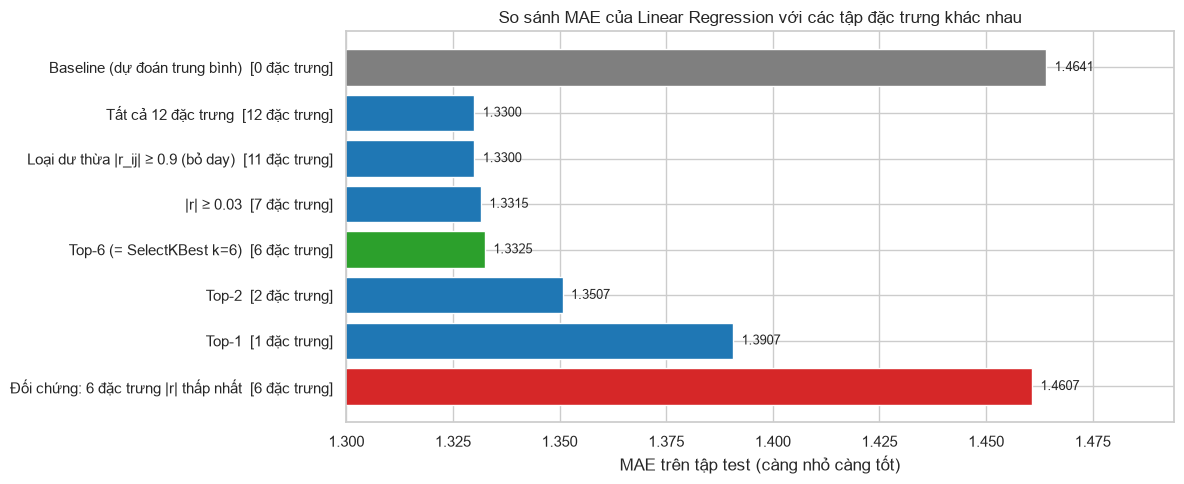

,số đặc trưng,MAE,MAE chênh so với tất cả,R2,% cải thiện,train_time_s,đặc trưng
tập đặc trưng,,,,,,,
Baseline (dự đoán trung bình),0,1.4641,0.1341,-0.0000,0.0000,0.0000,
Tất cả 12 đặc trưng,12,1.3300,0.0000,0.1494,100.0000,0.3551,"length, weight, count, looped, neighbors, weight_per_count, looped_ratio, year, day, month, weekday, is_ransom"
Loại dư thừa |r_ij| ≥ 0.9 (bỏ day),11,1.3300,0.0000,0.1494,99.9896,0.2902,"year, neighbors, weight, count, weight_per_count, length, is_ransom, month, looped_ratio, weekday, looped"
|r| ≥ 0.03,7,1.3315,0.0015,0.1477,98.8447,0.1482,"year, neighbors, weight, count, weight_per_count, length, is_ransom"
Top-6 (= SelectKBest k=6),6,1.3325,0.0025,0.1465,98.1292,0.1290,"year, neighbors, weight, count, weight_per_count, length"
Top-2,2,1.3507,0.0207,0.1253,84.5435,0.0457,"year, neighbors"
Top-1,1,1.3907,0.0607,0.0804,54.7289,0.0269,year
Đối chứng: 6 đặc trưng |r| thấp nhất,6,1.4607,0.1308,0.0043,2.4629,0.1261,"is_ransom, month, looped_ratio, day, weekday, looped"


In [19]:
no_day = drop_redundant(FEATURES, 0.9)
rows = [BASE, ALL,
        evaluate("Loại dư thừa |r_ij| ≥ 0.9 (bỏ day)", no_day)[0],
        thr_df.loc[thr_df["tập đặc trưng"] == "|r| ≥ 0.03"].iloc[0].to_dict(),
        evaluate(f"Top-{K_BEST} (= SelectKBest k={K_BEST})", RANKING[:K_BEST])[0],
        evaluate("Top-2", RANKING[:2])[0],
        evaluate("Top-1", RANKING[:1])[0],
        evaluate(f"Đối chứng: {K_BEST} đặc trưng |r| thấp nhất", RANKING[-K_BEST:])[0]]
summary_b2 = pd.DataFrame(rows)
summary_b2["% cải thiện"] = improvement(summary_b2["MAE"])
summary_b2["MAE chênh so với tất cả"] = summary_b2["MAE"] - ALL["MAE"]

colors = ["tab:gray" if n == 0 else "tab:red" if name.startswith("Đối chứng") else
          "tab:green" if name.startswith(f"Top-{K_BEST} ") else "tab:blue"
          for name, n in zip(summary_b2["tập đặc trưng"], summary_b2["số đặc trưng"])]
fig, ax = plt.subplots(figsize=(12, 5))
labels = [f"{a}  [{n} đặc trưng]" for a, n in zip(summary_b2["tập đặc trưng"], summary_b2["số đặc trưng"])]
ax.barh(labels[::-1], summary_b2["MAE"][::-1], color=colors[::-1])
for i, v in enumerate(summary_b2["MAE"][::-1]):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)
lo = summary_b2["MAE"].min()
ax.set(xlim=(lo - 0.03, summary_b2["MAE"].max() + 0.03), xlabel="MAE trên tập test (càng nhỏ càng tốt)",
       title="So sánh MAE của Linear Regression với các tập đặc trưng khác nhau")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/mae_subsets.png", dpi=120); plt.show()
summary_b2.set_index("tập đặc trưng")[["số đặc trưng", "MAE", "MAE chênh so với tất cả", "R2", "% cải thiện",
                                       "train_time_s", "đặc trưng"]]

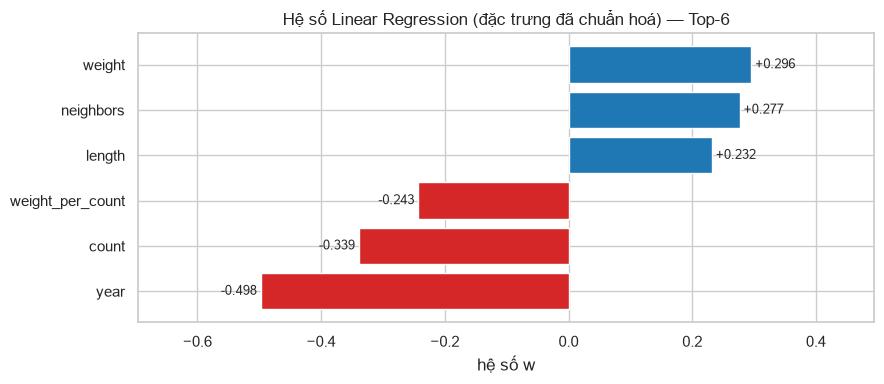

In [20]:
_, model_best = evaluate("best", RANKING[:K_BEST])
coef = pd.Series(model_best.named_steps["lr"].coef_, index=RANKING[:K_BEST]).sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(coef.index, coef.values, color=np.where(coef.values > 0, "tab:blue", "tab:red"))
for i, v in enumerate(coef.values):
    ax.text(v, i, f" {v:+.3f} ", va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.set(title=f"Hệ số Linear Regression (đặc trưng đã chuẩn hoá) — Top-{K_BEST}", xlabel="hệ số w")
ax.margins(x=0.25)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/lr_coefficients.png", dpi=120); plt.show()

In [21]:
# Xuất kết quả cho demo Streamlit (proj1/data/bai2)
EN = {"tập đặc trưng": "subset", "đặc trưng thêm vào": "added", "số đặc trưng": "n_features", "đặc trưng": "features",
      "% cải thiện": "improvement_pct", "MAE chênh so với tất cả": "mae_vs_all"}
corr_target.rename(columns={"hạng": "rank"}).rename_axis("feature").reset_index().to_csv(f"{APP_DIR}/corr_target.csv", index=False)
corr_all.to_csv(f"{APP_DIR}/corr_matrix.csv")
topk.rename(columns=EN).to_csv(f"{APP_DIR}/topk.csv", index=False)
summary_b2.rename(columns=EN).to_csv(f"{APP_DIR}/subsets.csv", index=False)
sample = pd.concat([pd.concat([X_train, y_train], axis=1).sample(100_000, random_state=RANDOM_STATE).assign(split="train"),
                    pd.concat([X_test, y_test], axis=1).sample(25_000, random_state=RANDOM_STATE).assign(split="test")])
sample.to_csv(f"{APP_DIR}/sample.csv.gz", index=False, float_format="%.6g")
print(sorted(os.listdir(APP_DIR)))

['corr_matrix.csv', 'corr_target.csv', 'sample.csv.gz', 'subsets.csv', 'topk.csv']


## 5. Kết luận

| Tập đặc trưng | Số đặc trưng | MAE (test) | % cải thiện |
|---|---|---|---|
| Baseline (dự đoán trung bình) | 0 | 1,4641 | 0% |
| Tất cả | 12 | 1,3300 | 100% |
| Loại dư thừa (bỏ `day`) | 11 | 1,3300 | ~100% |
| Ngưỡng \|r\| ≥ 0,03 | 7 | 1,3315 | 98,8% |
| **Top-6 theo \|r\| (đề xuất)** | **6** | **1,3325** | **98,1%** |
| Top-2 (`year`, `neighbors`) | 2 | 1,3507 | 84,5% |
| Đối chứng: 6 đặc trưng \|r\| thấp nhất | 6 | 1,4607 | 2,5% |

1. **Phương pháp:** xếp hạng đặc trưng theo |r| Pearson với mục tiêu (*relevance*) và loại các đặc trưng tương quan
   mạnh với nhau (*redundancy*). Kết quả trùng với `SelectKBest(f_regression)` của scikit-learn.
2. **Tập đặc trưng đề xuất — Top-6:** `year, neighbors, weight, count, weight_per_count, length`. Chỉ dùng **một nửa**
   số đặc trưng mà MAE chỉ tăng 0,0025 (0,19%); train nhanh hơn, ít tham số hơn, dễ giải thích hơn.
3. **Đặc trưng dư thừa:** `day` (trùng `month`, r = 0,996) bỏ đi mà MAE không đổi.
4. **Kiểm chứng:** 6 đặc trưng có |r| thấp nhất cho MAE gần bằng baseline; Top-6 theo Spearman kém hơn Top-6 theo
   Pearson → với Linear Regression, tương quan Pearson phản ánh đúng mức độ quan trọng của đặc trưng.
5. **Hạn chế:** R² ≈ 0,15 — các đặc trưng chỉ giải thích ~15% biến động của income (quan hệ yếu/phi tuyến; income còn
   phụ thuộc yếu tố ngoài dữ liệu như giá BTC, hành vi chủ ví). Tương quan chỉ xét **từng cặp** và chỉ đo quan hệ
   **tuyến tính** → có thể bổ sung Mutual Information, RFE hoặc `SelectFromModel` với mô hình cây.